# Introduction

**Dimension Reduction:**
There are many ways to achieve dimensionality reduction, but most of these techniques fall into one of two classes 
* Feature Elimination
* Feature Extraction

**Principal Component Analysis (PCA):** 
PCA is a dimension reduction technique extensionally used for visualization of high dimensional data. It is a feature extraction technique — it combines all input variable in a specific way, drop the least important variables while retaining the most valuable ones. In this method we calculate eigenvectors and eigenvalues of the covariance matrix. Once eigenvectors are found from the covariance matrix, the nextstep is to order them by eigenvalue, highest to lowest. This gives you the components in order of significance.The eigenvector with the highest eigenvalue is the principal component of the data set.

**t-Distributed Stochastic Neighbor Embedding (t-SNE):**
t-SNE is a non-linear, unsupervised technique primarily used for data exploration and visualization of high-dimensional data. It provides you an intuition of how the data is arranged in a high-dimensional space. The t-SNE algorithm calculates a similarity measure between points in high dimensional space using Gaussian distribution then in the low dimensional space using Cauchy distribution. Finally it measures the probability distribution of the two dimensional spaces by Kullback-Liebler divergence and optimize the KL cost function using gradient descent.

**PCA vs t-SNE:**
t-SNE differs from PCA by preserving only small pairwise distances or local similarities whereas PCA is concerned with preserving large pairwise distances to maximize variance. PCA is a linear dimension reduction technique that seeks to maximize variance and preserves large pairwise distances. In other words, things that are different end up far apart. This can lead to poor visualization especially when dealing with non-linear manifold structures. 

> *In this notebook we will see the comparision between PCA and t-SNE on MNIST digits dataset*




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import manifold
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition

> Import data as Input

* MNIST digits dataset is used for the purpose which consist of 784 pixel values and 42000 entries in train data

In [2]:
data = pd.read_csv('../input/digit-recognizer/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
df_labels = data.label
df_data = data.drop('label', axis = 1)


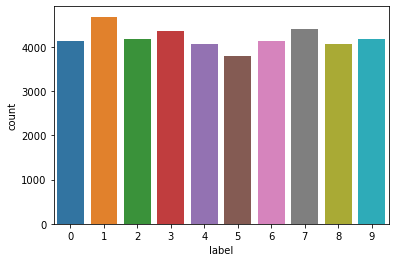

In [4]:
#Count plot for the labels 
sns.countplot(df_labels)

Standardizing the data into a 2D array of shape 10000x784 as 10000 images have been extracted of shape 28x28 pixels. Flattening 28x28 pixels give 784 data points.

In [5]:
#extracting top 10000 data points 
df_data = df_data.head(10000)
df_labels = df_labels.head(10000)
pixel_df = StandardScaler().fit_transform(df_data)
pixel_df.shape

(10000, 784)

In [6]:
sample_data = pixel_df

**Implementation of PCA**

In [7]:
pca = decomposition.PCA(n_components = 2, random_state = 42)

In [8]:
pca_data = pca.fit_transform(sample_data)
print("shape of pca_reduced.shape = ", pca_data.shape)

shape of pca_reduced.shape =  (10000, 2)


           X         Y  labels
0  -4.949490 -5.447558     1.0
1  18.966328  6.833385     0.0
2  -7.528044 -2.051286     1.0
3  -0.715478  5.554786     4.0
4  26.253751  7.291697     0.0
5   1.068227 -0.601369     0.0
6  -6.276303  6.158837     7.0
7  -0.047313  4.606848     3.0
8  -0.802747 -1.392007     5.0
9   3.038447 -2.074995     3.0


/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:243: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


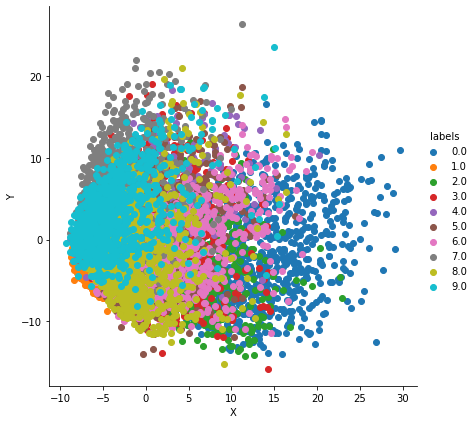

In [9]:
# attaching the label for each 2-d data point 
pca_data = np.column_stack((pca_data, df_labels))

# creating a new data frame for plotting of data points
pca_df = pd.DataFrame(data=pca_data, columns=("X", "Y", "labels"))
print(pca_df.head(10))
sns.FacetGrid(pca_df, hue="labels", size=6).map(plt.scatter, 'X', 'Y').add_legend()
plt.show()

**Implementation of t-SNE**

In [10]:
tsne = manifold.TSNE(n_components = 2, random_state = 42, verbose = 2, n_iter = 2000)
transformed_data = tsne.fit_transform(sample_data)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 10000 samples in 1.543s...
[t-SNE] Computed neighbors for 10000 samples in 180.623s...
[t-SNE] Computed conditional probabilities for sample 1000 / 10000
[t-SNE] Computed conditional probabilities for sample 2000 / 10000
[t-SNE] Computed conditional probabilities for sample 3000 / 10000
[t-SNE] Computed conditional probabilities for sample 4000 / 10000
[t-SNE] Computed conditional probabilities for sample 5000 / 10000
[t-SNE] Computed conditional probabilities for sample 6000 / 10000
[t-SNE] Computed conditional probabilities for sample 7000 / 10000
[t-SNE] Computed conditional probabilities for sample 8000 / 10000
[t-SNE] Computed conditional probabilities for sample 9000 / 10000
[t-SNE] Computed conditional probabilities for sample 10000 / 10000
[t-SNE] Mean sigma: 5.095107
[t-SNE] Computed conditional probabilities in 0.668s
[t-SNE] Iteration 50: error = 97.1117249, gradient norm = 0.0332864 (50 iterations in 6.738s)
[t-SNE] 

In [11]:
#Creation of new dataframe for plotting of data points
tsne_df = pd.DataFrame(
    np.column_stack((transformed_data, df_labels)),
    columns = ['x', 'y', 'labels'])
tsne_df.loc[:, 'labels']= tsne_df.labels.astype(int)
print(tsne_df.head(10))


           x           y  labels
0 -23.487684   -5.725172       1
1  23.596231  -94.606003       0
2 -83.231758  -13.757490       1
3 -72.798515   44.552700       4
4  31.947041 -104.392006       0
5  18.104330  -74.902122       0
6 -23.574133   87.560249       7
7  13.910466   12.972529       3
8  63.566826    8.578925       5
9  31.751112  -21.639307       3


/opt/conda/lib/python3.7/site-packages/seaborn/axisgrid.py:243: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


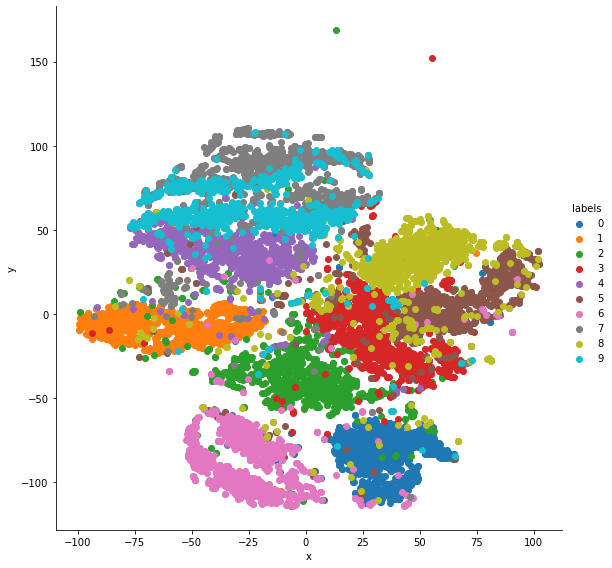

In [12]:
grid = sns.FacetGrid(tsne_df, hue='labels', size = 8)
grid.map(plt.scatter, 'x', 'y').add_legend()